In [55]:
import sys
sys.path.insert(0, '..')

import ast
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from matplotlib import rcParams
from scipy import stats
from itertools import chain


from DB_connection import DB_connection
from diversity_metrics import compute_user_shanon_entropy
from data.base_mnl_a import base_au_80_80_test_40 as bases_dict
from data.base_mnl_a import entropy_au_80_80 as shanon_entropy_dict
from tqdm import tqdm



db_connection = DB_connection()
active_users  =  db_connection.get_active_users(80,80)



# Usefull functions

In [ ]:
simulation_types = ['SVD','mmr','mmr_EDC','TDERank','PI-adaptDiv']

number_pattern = re.compile(
    r'(?<![\w.])[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?'
)

def _parse_ratings_item(item):
    # Already list/array
    if isinstance(item, (list, np.ndarray)):
        return np.array(item, dtype=float)

    # Scalar number
    if isinstance(item, (int, float)):
        return np.array([float(item)], dtype=float)

    # Everything else → treat as string and extract numbers
    s = str(item)
    nums = number_pattern.findall(s)
    if not nums:
        # nothing numeric found → return NaN so mean can handle it
        return np.array([np.nan], dtype=float)

    return np.array([float(x) for x in nums], dtype=float)



def show_all_simulations_for_one_user_for_all_parameters(user_id, simulation_type):
    diversity_simulations = {}
    precision_simulations = {}
    recommended_items_simulations = {}
    no_choices_simulations = {}
    
    
    query = f'''
        SELECT DISTINCT(parameters_id) 
        FROM simulated_behaviors 
        WHERE user_id = '{user_id}'
          AND simulation_type = '{simulation_type}'
        ORDER BY parameters_id ASC;
    '''
    parameters_ids = list(db_connection.select(query)['parameters_id'])

    # Correct empty check
    if not parameters_ids or parameters_ids == [None]:
        query = f'''
            SELECT * FROM simulated_behaviors
            WHERE user_id = '{user_id}'
              AND simulation_type = '{simulation_type}'
              AND simulation_number = 1;
        '''
        simulation = db_connection.select(query)
        
        diversity_simulations = list(simulation['diversity'])[0:30]

        initial_ratings = list(simulation['initial_ratings'])[0:30]
        precision_evolution = []
        for item in initial_ratings:
            ratings_arr = _parse_ratings_item(item)
            precision_evolution.append(np.mean(ratings_arr))
        
        recommended_items = list(simulation['recommended_items'])[0:30]
        recommended_items_evolution = []
        for items in recommended_items:
            recommended_items_evolution.append(ast.literal_eval(items)[0:-1])

        probabities = list(simulation['probabilities'])[0:30]
        no_choices_evolution = []
        for prob in probabities:
            no_choices_evolution.append(_parse_ratings_item(prob)[-1])
        

        return diversity_simulations, precision_evolution, recommended_items_evolution, no_choices_evolution
    
    else:
        for param_id in parameters_ids:
            query = f'''
                SELECT * FROM simulated_behaviors
                WHERE user_id = '{user_id}'
                  AND simulation_type = '{simulation_type}'
                  AND parameters_id = '{param_id}'
                  AND simulation_number = 1;
            '''
            simulation = db_connection.select(query)
            diversity_simulations[param_id] = list(simulation['diversity'])[0:30]

            initial_ratings = list(simulation['initial_ratings'])[0:30]
            precision_evolution = []
            for item in initial_ratings:
                ratings_arr = _parse_ratings_item(item)
                precision_evolution.append(np.mean(ratings_arr))
            precision_simulations[param_id] = precision_evolution

            recommended_items = list(simulation['recommended_items'])[0:30]
            recommended_items_evolution = []
            for items in recommended_items:
                recommended_items_evolution.append(ast.literal_eval(items)[0:-1])
                
            recommended_items_simulations[param_id] = recommended_items_evolution

            probabities = list(simulation['probabilities'])[0:30]
            no_choices_evolution = []
            for prob in probabities:
                no_choices_evolution.append(_parse_ratings_item(prob)[-1])
            no_choices_simulations[param_id] = no_choices_evolution
        

        return diversity_simulations, precision_simulations, recommended_items_simulations, no_choices_simulations
    

def get_all_diversity_and_precision_evolutions():
    all_diversity_evolutions = {}
    all_precision_evolutions = {}
    all_recommended_items_evolutions = {}
    all_prob_no_choice_evolutions = {}
    for user in tqdm(active_users):
        diversities_per_user = {}
        precisions_per_user = {}
        recommended_items_per_user = {}
        no_choices_per_user = {}
        for simulation_type in simulation_types:
            all_user_simulations_div, all_user_simulations_precision, recommended_items_simulations, no_choices_simulations = show_all_simulations_for_one_user_for_all_parameters(user,simulation_type)
            diversities_per_user[simulation_type] = all_user_simulations_div
            precisions_per_user[simulation_type] = all_user_simulations_precision
            recommended_items_per_user[simulation_type] = recommended_items_simulations
            no_choices_per_user[simulation_type] = no_choices_simulations



        all_diversity_evolutions[user] = diversities_per_user
        all_precision_evolutions[user] = precisions_per_user
        all_recommended_items_evolutions[user] = recommended_items_per_user
        all_prob_no_choice_evolutions[user] = no_choices_per_user
        
    return all_diversity_evolutions, all_precision_evolutions, all_recommended_items_evolutions, all_prob_no_choice_evolutions







###### UNCOMMENT AND RUN TO SAVE RESULTS ONLY IF YOU HAVE RE-RUN NEW SIMULATIONS ######

#all_diversity_evolutions,all_precision_evolutions, all_recommended_items_evolutions, all_prob_no_choice_evolutions = get_all_diversity_and_precision_evolutions()

#with open("all_diversity_evolutions.pkl", "wb") as f:
#    pickle.dump(all_diversity_evolutions, f)

#with open("all_precision_evolutions.pkl", "wb") as f:
#    pickle.dump(all_precision_evolutions, f)

#with open("all_recommended_items_evolutions.pkl", "wb") as f:
#    pickle.dump(all_recommended_items_evolutions, f)

#with open("all_prob_no_choice_evolutions.pkl", "wb") as f:
#    pickle.dump(all_prob_no_choice_evolutions, f)



# Load Data

In [56]:
with open("all_diversity_evolutions.pkl", "rb") as f:
    all_diversity_evolutions = pickle.load(f)

with open("all_precision_evolutions.pkl", "rb") as f:
    all_precision_evolutions = pickle.load(f)

with open("all_recommended_items_evolutions.pkl", "rb") as f:
    all_recommended_items_evolutions = pickle.load(f)

with open("all_prob_no_choice_evolutions.pkl", "rb") as f:
    all_prob_no_choice_evolutions = pickle.load(f)


In [57]:
def get_all_diversity_and_precision_evolutions():
    all_diversity_evolutions = {}
    all_precision_evolutions = {}
    for user in tqdm(active_users):
        diversities_per_user = {}
        precisions_per_user = {}
        for simulation_type in simulation_types:
            all_user_simulations_div, all_user_simulations_precision = show_all_simulations_for_one_user_for_all_parameters(user,simulation_type)
            diversities_per_user[simulation_type] = all_user_simulations_div
            precisions_per_user[simulation_type] = all_user_simulations_precision

        all_diversity_evolutions[user] = diversities_per_user
        all_precision_evolutions[user] = precisions_per_user
        
    return all_diversity_evolutions, all_precision_evolutions


def get_final_diversity(users,simulation_type, parameters = None):
    final_diversity_all_users = {}
    if parameters is None:
        for user in users:
            if type(all_diversity_evolutions[user][simulation_type]) == list:
                diversities = np.array(all_diversity_evolutions[user][simulation_type])
                final_diversity = np.mean(diversities[-1])
            else:
                diversities = np.array(list(all_diversity_evolutions[user][simulation_type].values()))
                final_diversity = np.mean(diversities[:,-1])
            final_diversity_all_users[user] = final_diversity
        return final_diversity_all_users
            
    else:
        for user in users:
            diversities = all_diversity_evolutions[user][simulation_type][parameters]
            final_diversity = diversities[-1]
            final_diversity_all_users[user] = final_diversity
        return final_diversity_all_users
    

def get_initial_diversity(users,simulation_type, parameters = None):
    initial_diversity_all_users = {}
    if parameters is None:
        for user in users:
            if type(all_diversity_evolutions[user][simulation_type]) == list:
                diversities = np.array(all_diversity_evolutions[user][simulation_type])
                initial_diversity = np.mean(diversities[0])
            else:
                diversities = np.array(list(all_diversity_evolutions[user][simulation_type].values()))
                initial_diversity = np.mean(diversities[:,0])
            initial_diversity_all_users[user] = initial_diversity
        return initial_diversity_all_users
            
    else:
        for user in users:
            diversities = all_diversity_evolutions[user][simulation_type][parameters]
            initial_diversity = diversities[0]
            initial_diversity_all_users[user] = initial_diversity
        return initial_diversity_all_users


def get_diversity_change(users,simulation_type, parameters = None):
    diversity_change_all_users = {}
    initial_diversity_all_users = get_initial_diversity(users,simulation_type, parameters)
    final_diversity_all_users = get_final_diversity(users,simulation_type, parameters)
    for user in users:
        diversity_change_all_users[user] = final_diversity_all_users[user] - initial_diversity_all_users[user]
    return diversity_change_all_users



def get_diversity_evolutions(users,simulation_type, parameters = None):
    diversity_evolutions_all_users = {}
    if parameters is None:
        for user in users:
            if type(all_diversity_evolutions[user][simulation_type]) == list:
                diversities = np.array(all_diversity_evolutions[user][simulation_type])
            else:
                diversities = np.mean(np.array(list(all_diversity_evolutions[user][simulation_type].values())), axis=0)
            diversity_evolutions_all_users[user] = diversities
        return diversity_evolutions_all_users
            
    else:
        for user in users:
            diversities = all_diversity_evolutions[user][simulation_type][parameters]
            diversity_evolutions_all_users[user] = diversities
        return diversity_evolutions_all_users
    
    
def get_mean_diversity_evolutions(users,simulation_type, parameters = None):
    if parameters is None:
        all_simulations_array = np.array(list(get_diversity_evolutions(users,simulation_type).values()))
        return np.mean(all_simulations_array, axis=0)
    else:
        all_simulations_array = np.array(list(get_diversity_evolutions(users,simulation_type,parameters).values()))
        return np.mean(all_simulations_array, axis=0)
    


item_df = db_connection.select("SELECT * FROM articles")
itemID_categories_dict = dict(zip(item_df["article_id"],item_df["category"]))

categories = list(db_connection.select('SELECT DISTINCT category FROM articles')["category"])

def get_initial_recommended_items(user):
    query =f"SELECT * FROM behaviors WHERE user_id = '{user}' "
    recommended_items = list(db_connection.select(query)["recommended_items"])
    flatten_recommended_items = []
    for item in recommended_items:
        flatten_recommended_items.append(item.split(" "))
    return flatten_recommended_items


def get_initial_recommended_items_for_all_users(users):
    initial_recommended_items_all_users = {}
    for user in users:
        initial_recommended_items = get_initial_recommended_items(user)
        initial_recommended_items_all_users[user] = initial_recommended_items
    return initial_recommended_items_all_users




def compute_recommended_shannon_entropy(recommended_items):
    """
    Compute Shannon entropy of the distribution of categories
    among the recommended items.
    """

    # Extract categories for the recommended item IDs
  
    rec_categories = [itemID_categories_dict[int(item)] for item in recommended_items]

    # Count occurrences of each category
    counts = {cat: rec_categories.count(cat) for cat in categories}
    total = len(recommended_items)

    # Convert to probabilities (ignore zero counts)
    probs = np.array([c / total for c in counts.values() if c > 0])

    # Shannon entropy (base e or base 2—your choice)
    #entropy = -np.sum(probs * np.log(probs))   # natural log → nats
    entropy = -np.sum(probs * np.log2(probs))/np.log2(len(categories))  # uncomment for bits

    return entropy



def get_recommended_diversity_evolutions(users,simulation_type, rolling_window, parameters = None):
    all_recommended_diversity_evolutions_window = {}
    all_recommended_diversity_evolutions = {}
    if parameters is None:
        for user in users:
            all_recommended_items = all_recommended_items_evolutions[user][simulation_type]
            if type(all_recommended_items) == list:
                diversity_window_evolution = []
                diversity_evolution = []
                initial_recomended_items = get_initial_recommended_items(user)
                recommended_items = initial_recomended_items + all_recommended_items
                #recommended_items = all_recommended_items.copy()
                for i in range(len(recommended_items)):
                    if i < len(recommended_items)- rolling_window:
                        window_items = recommended_items[i:i+rolling_window]
                        items = recommended_items[0:i]
                    # Flatten the list of lists
                    flat_window_items = [item for sublist in window_items for item in sublist]
                    flat_items = [item for sublist in items for item in sublist]
                    if i > len(initial_recomended_items)-rolling_window-1:
                        diversity_window = compute_recommended_shannon_entropy(flat_window_items)
                        diversity = compute_recommended_shannon_entropy(flat_items)
                        diversity_window_evolution.append(diversity_window)
                        diversity_evolution.append(diversity)
                all_recommended_diversity_evolutions_window[user] = diversity_window_evolution
                all_recommended_diversity_evolutions[user] = diversity_evolution
            elif type(all_recommended_items) == dict:
                all_diversity_window_evolution = []
                all_diversity_evolution = []
                for param in list(all_recommended_items.keys()):
                    diversity_window_evolution = []
                    diversity_evolution = []
                    initial_recomended_items = get_initial_recommended_items(user)
                    recommended_items = initial_recomended_items + all_recommended_items[param]
                    for i in range(len(recommended_items)):
                        if i < len(recommended_items)- rolling_window:
                            window_items = recommended_items[i:i+rolling_window]
                            items = recommended_items[0:i+rolling_window]
                        # Flatten the list of lists
                        flat_window_items = [item for sublist in window_items for item in sublist]
                        flat_items = [item for sublist in items for item in sublist]
                        if i > len(initial_recomended_items)-rolling_window-1:
                            diversity_window = compute_recommended_shannon_entropy(flat_window_items)
                            diversity = compute_recommended_shannon_entropy(flat_items)
                            diversity_window_evolution.append(diversity_window)
                            diversity_evolution.append(diversity)
                    all_diversity_window_evolution.append(diversity_window_evolution)
                    all_diversity_evolution.append(diversity_evolution)
                all_recommended_diversity_evolutions_window[user] = list(np.mean(np.array(all_diversity_window_evolution), axis=0))
                all_recommended_diversity_evolutions[user] = list(np.mean(np.array(all_diversity_evolution), axis=0))
        return (all_recommended_diversity_evolutions, all_recommended_diversity_evolutions_window,
                np.mean(np.array(list(all_recommended_diversity_evolutions.values())),axis=0),
                np.mean(np.array(list(all_recommended_diversity_evolutions_window.values())),axis=0))
    
                

                

# Quadrant definition

In [58]:
Q1 = []
Q2 = []
Q3 = []
Q4 = []
mat = np.zeros((2,2))
for user in active_users:
    E = shanon_entropy_dict[user]
    a = bases_dict[user]
    E_threshold = 0.5
    a_threshold_max = 14
    a_threshold_min = 14


    if a<a_threshold_max and E<E_threshold:
        mat[0][0] += 1
        Q1.append(user)
    elif a<a_threshold_max and E>E_threshold:
        mat[0][1] += 1
        Q2.append(user)
    elif a>a_threshold_min and E<E_threshold:
        mat[1][0] += 1
        Q3.append(user)
    elif a>a_threshold_min and E>E_threshold:
        mat[1][1] += 1
        Q4.append(user)


In [59]:
# =======================
# Params
# =======================

default_colors = rcParams['axes.prop_cycle'].by_key()['color']

lambdas = ["lambda_0.1","lambda_0.2","lambda_0.3","lambda_0.4","lambda_0.5",
           "lambda_0.6","lambda_0.7","lambda_0.8","lambda_0.9","lambda_1"]
surpluses = ["surplus_1","surplus_5","surplus_10","surplus_20"]
pi_params = [
    "K_p=20-theta=10","K_p=20-theta=5",
    "K_p=10-theta=10","K_p=10-theta=5",
    "K_p=5-theta=10","K_p=5-theta=5"
]

algo_parameters_structure = {
    'SVD': [None],
    'mmr': lambdas,
    'mmr_EDC': lambdas,
    'TDERank': surpluses,
    'PI-adaptDiv': pi_params
}

algo_colors = {
    'SVD': default_colors[0],
    'mmr': default_colors[1],
    'mmr_EDC': default_colors[2],
    'TDERank': default_colors[4],
    'PI-adaptDiv': default_colors[3]
}

# =======================
# Helpers
# =======================
def mean_ci(values, confidence=0.95):
    vals = np.asarray(list(values), dtype=float)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    if n == 1:
        m = float(vals[0])
        return m, m, m
    m = float(np.mean(vals))
    se = float(stats.sem(vals))
    tcrit = stats.t.ppf((1 + confidence) / 2.0, df=n - 1)
    half = float(tcrit * se)
    return m, m - half, m + half

def _flatten(lol):
    return list(chain.from_iterable(lol))


def _plot_point(ax, x_vals, y_vals, *, color, marker, with_ci, confidence,
                alpha_ci=0.4, size=250, edgecolor="black", lw=1.0):
    x_list = [float(v) for v in x_vals]
    y_list = [float(v) for v in y_vals]

    if with_ci:
        x_m, x_lo, x_hi = mean_ci(x_list, confidence)
        y_m, y_lo, y_hi = mean_ci(y_list, confidence)

        ax.errorbar(
            x_m, y_m,
            xerr=[[x_m - x_lo], [x_hi - x_m]],
            yerr=[[y_m - y_lo], [y_hi - y_m]],
            fmt="none",
            ecolor=color,
            elinewidth=1,
            capsize=3,
            alpha=alpha_ci,
            zorder=1
        )

    ax.scatter(
        x_m if with_ci else np.mean(x_list),
        y_m if with_ci else np.mean(y_list),
        s=size,
        marker=marker,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=lw,
        zorder=2
    )
    return x_m, y_m



# ================== #
# Parameter markers  #
# ================== #
LAMBDA_MARKERS  = ['o','s','^','v','<','>','D','P','X','*']  # 10
SURPLUS_MARKERS = ['o','s','^','D']                          # 4
PI_MARKERS      = ['o','s','^','v','D','P']                  # 6

lambda_marker  = dict(zip(lambdas, LAMBDA_MARKERS))
surplus_marker = dict(zip(surpluses, SURPLUS_MARKERS))
pi_marker      = dict(zip(pi_params, PI_MARKERS))


quad_users = {
    "Q1": Q1,
    "Q2": Q2,
    "Q3": Q3,
    "Q4": Q4,
}


## RQ1.1

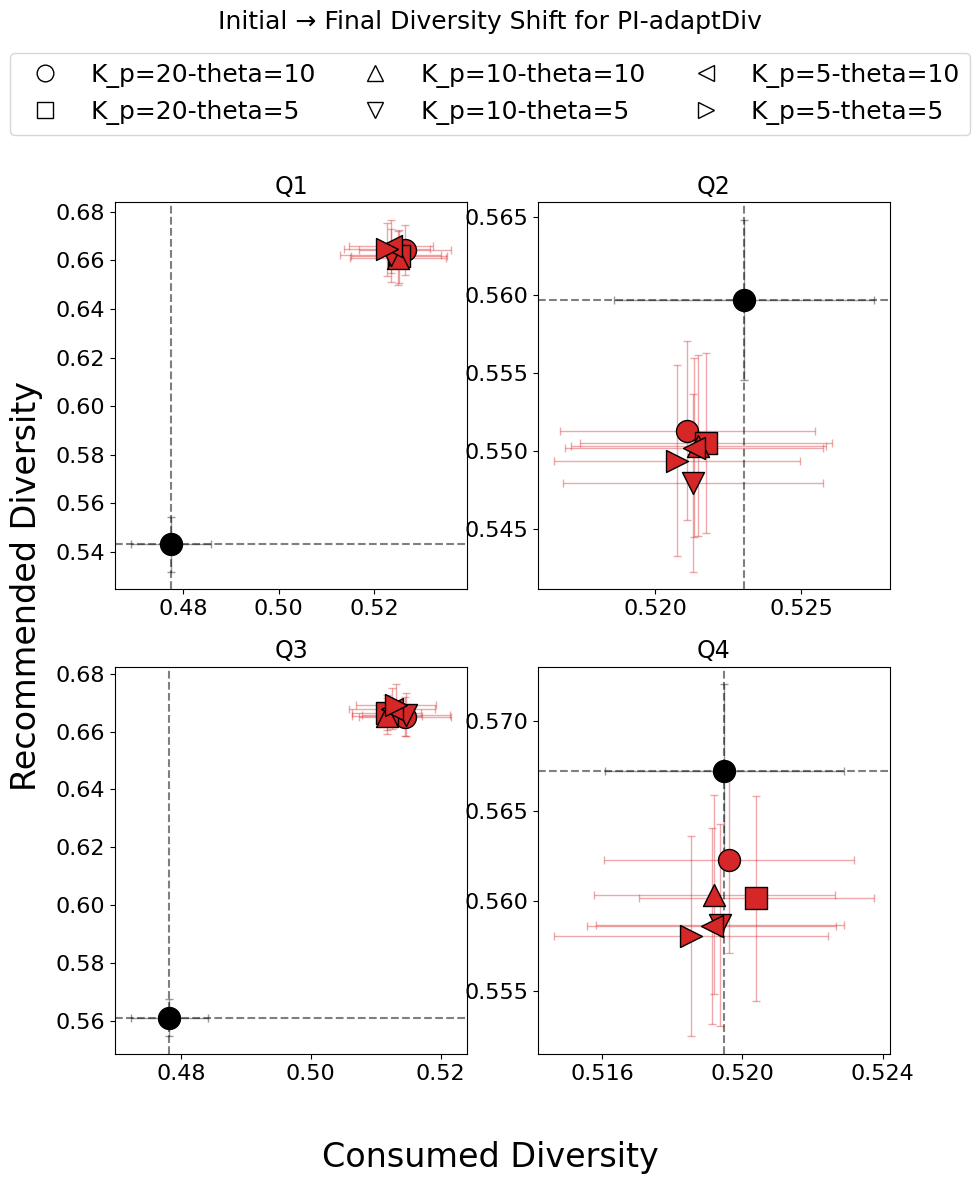

In [60]:

# =======================
# Main plot
# =======================
def plot_diversity_shift_by_quadrant_style_matched(
    quad_users,
    algo_parameters_structure,
    algo_colors,
    *,
    title="Initial → Final Diversity Shift (By Quadrant)",
    with_ci=True,
    confidence=0.95,
    alpha_ci=0.4,
):

    MARKERS = ['o', 's', '^', 'v', '<', '>', 'D', 'P', 'X', '*', 'h', '+']

    param_to_marker_by_algo = {}
    ordered_params_by_algo = {}

    for alg, params in algo_parameters_structure.items():
        uniq = []
        for p in params:
            if p is not None and p not in uniq:
                uniq.append(p)
        if len(uniq) > len(MARKERS):
            raise ValueError("Not enough marker shapes defined.")
        ordered_params_by_algo[alg] = uniq
        param_to_marker_by_algo[alg] = {p: MARKERS[i] for i, p in enumerate(uniq)}

    fig, axs = plt.subplots(2, 2, figsize=(10, 12))
    for ax in axs.ravel():
        ax.tick_params(axis="both", which="major", labelsize=16)
    fig.subplots_adjust(top=0.82)

    quad_axes = {"Q1": axs[0, 0], "Q2": axs[0, 1], "Q3": axs[1, 0], "Q4": axs[1, 1]}

    algo_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='black', markeredgecolor='black',
               markersize=12, label='Initial')
    ]
    for alg in algo_parameters_structure:
        algo_handles.append(
            Line2D([0], [0], marker='o', linestyle='None',
                   markerfacecolor=algo_colors[alg], markeredgecolor='black',
                   markersize=12, label=alg)
        )

    param_handles = []
    for alg in algo_parameters_structure:
        for p in ordered_params_by_algo[alg]:
            param_handles.append(
                Line2D([0], [0],
                       marker=param_to_marker_by_algo[alg][p],
                       linestyle='None',
                       color='black',
                       markerfacecolor='white',
                       markeredgecolor='black',
                       markersize=12,
                       label=str(p))
            )

    for quad_name, users in quad_users.items():
        ax = quad_axes[quad_name]

        if quad_name in ["Q2", "Q4"]:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=3))

        if not users:
            ax.set_title(f"{quad_name} (empty)", fontsize=16)
            ax.axis("off")
            continue

        initial_flat = {}
        initial_rec = {}
        for u in users:
            flat = _flatten(get_initial_recommended_items(u))
            initial_flat[u] = flat
            initial_rec[u] = compute_recommended_shannon_entropy(flat)

        initial_cons = get_initial_diversity(users, "SVD")

        x0, y0 = _plot_point(
            ax,
            initial_cons.values(),
            initial_rec.values(),
            color="black",
            marker="o",
            with_ci=with_ci,
            confidence=confidence,
            alpha_ci=alpha_ci,
        )

        ax.axvline(x=x0, color="black", linestyle="--", alpha=0.5)
        ax.axhline(y=y0, color="black", linestyle="--", alpha=0.5)

        for alg, params in tqdm(algo_parameters_structure.items(), desc=quad_name, leave=False):
            color = algo_colors[alg]
            for p in params:
                final_rec = {}
                for u in users:
                    sim = (
                        all_recommended_items_evolutions[u][alg]
                        if p is None
                        else all_recommended_items_evolutions[u][alg][p]
                    )
                    final_rec[u] = compute_recommended_shannon_entropy(initial_flat[u] + _flatten(sim))

                final_cons = get_final_diversity(users, alg) if p is None else get_final_diversity(users, alg, p)
                marker = "o" if p is None else param_to_marker_by_algo[alg][p]

                _plot_point(
                    ax,
                    final_cons.values(),
                    final_rec.values(),
                    color=color,
                    marker=marker,
                    with_ci=with_ci,
                    confidence=confidence,
                    alpha_ci=alpha_ci,
                )

        ax.set_title(quad_name, fontsize=17)
    
    fig.supxlabel("Consumed Diversity", fontsize=24)
    fig.supylabel("Recommended Diversity", fontsize=24)
    fig.suptitle(title, fontsize=18)


    fig.legend(
    handles=param_handles,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=3,                
    frameon=True,
    fontsize=18,
    title_fontsize=14,
    handletextpad=0.8,
    columnspacing=1.4
)

    plt.show()

# =======================
# Call example (your case)
# =======================
plot_diversity_shift_by_quadrant_style_matched(
    quad_users=quad_users,
    algo_parameters_structure={'PI-adaptDiv': pi_params},
    algo_colors={'PI-adaptDiv': default_colors[3]},
    title="Initial → Final Diversity Shift for PI-adaptDiv",
    with_ci=True,
    confidence=0.95
)


## RQ1.2

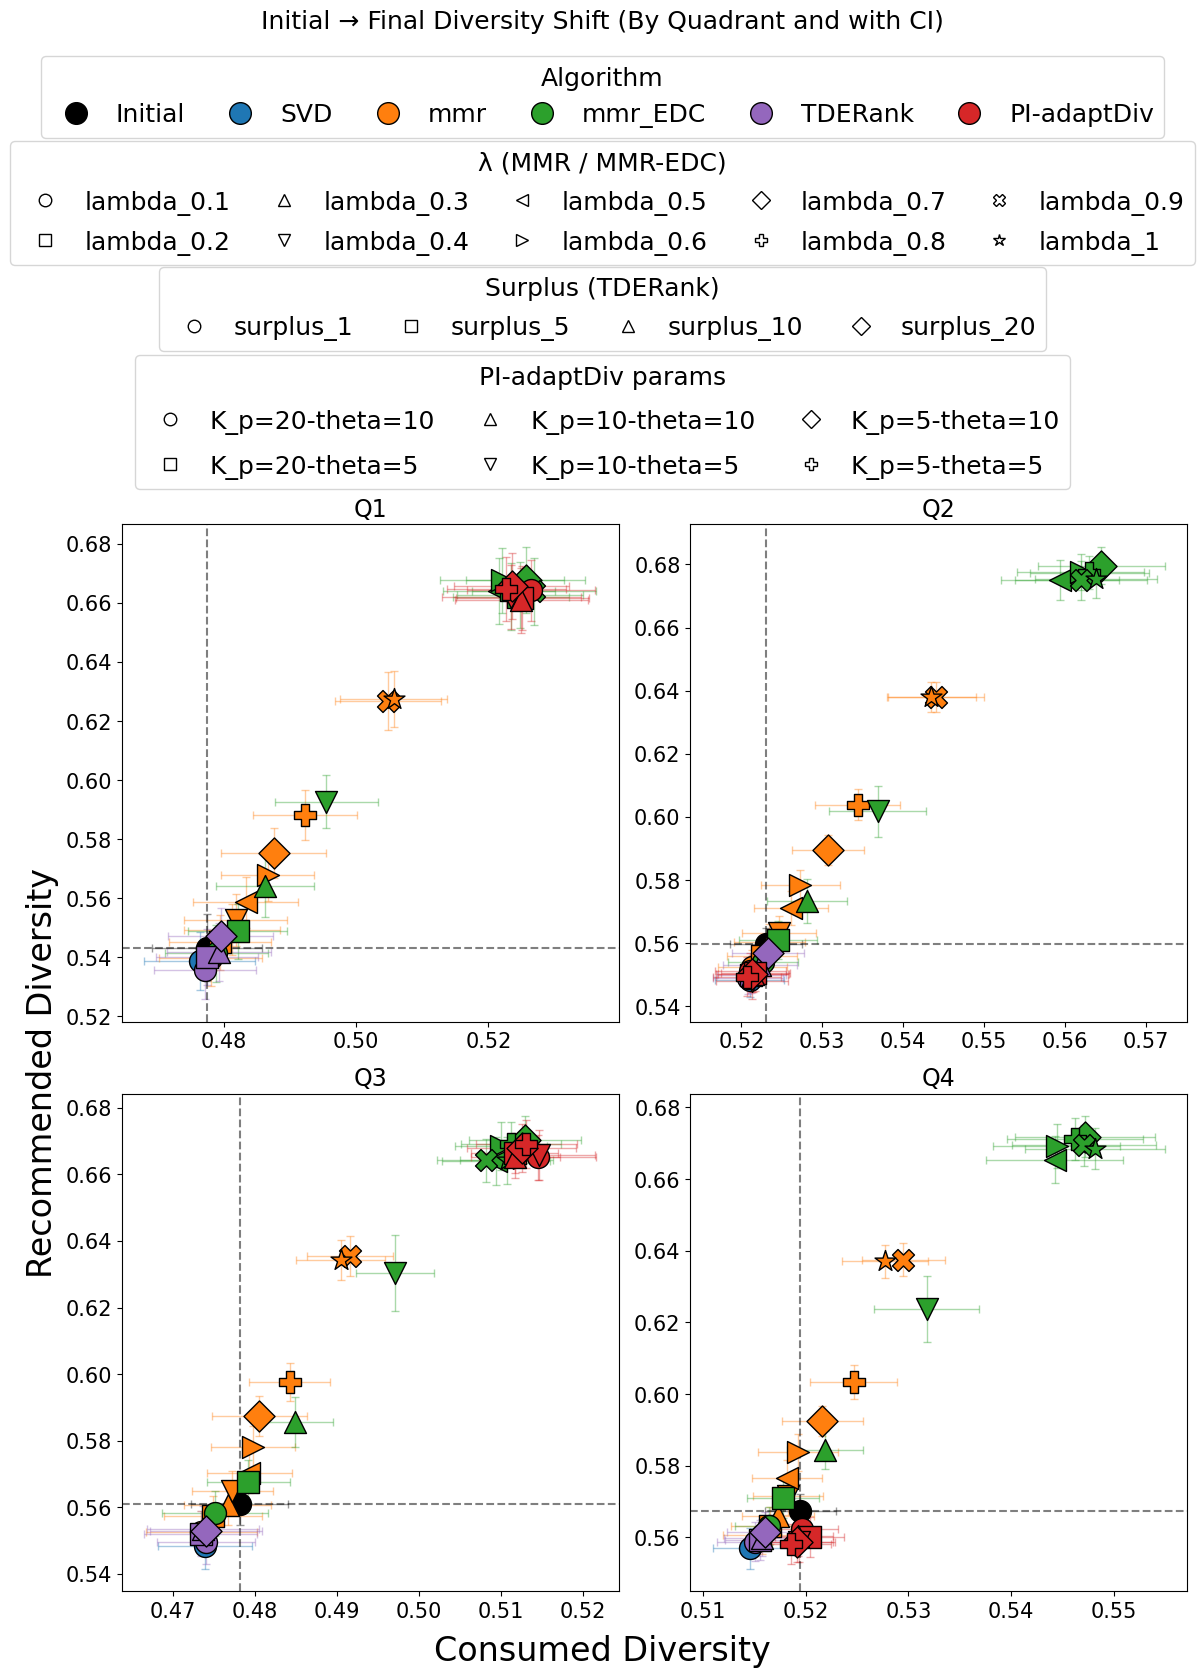

In [61]:

def marker_for(algo, p):
    if algo in ["mmr", "mmr_EDC"]:
        return lambda_marker[p]
    if algo == "TDERank":
        return surplus_marker[p]
    if algo == "PI-adaptDiv":
        return pi_marker[p]
    return "o"

# =======================
# Plot by quadrant (with the legend style you want)
#   - Algorithm legend (colors) above
#   - One legend row PER algo-parameter family:
#       * λ legend: TWO lines (ncol=5)
#       * Surplus legend: ONE line (ncol=4)
#       * PI params legend: ONE line (ncol=6)
# =======================
def plot_diversity_shift_by_quadrant_style_matched(
    quad_users,
    algo_parameters_structure,
    algo_colors,
    *,
    title="Initial → Final Diversity Shift (By Quadrant)",
    with_ci=True,
    confidence=0.95,
    alpha_ci=0.4,
    algo_fontsize=18,
    param_fontsize=18,
    axis_fontsize=24,
    quad_title_fontsize=17,
    main_title_fontsize=18,
):
    fig, axs = plt.subplots(2, 2, figsize=(12, 17), sharex=False, sharey=False)
    for ax in axs.ravel():
        ax.tick_params(axis="both", which="major", labelsize=15)
    quad_axes = {"Q1": axs[0, 0], "Q2": axs[0, 1], "Q3": axs[1, 0], "Q4": axs[1, 1]}

    # ---- Plot each quadrant ----
    for quad_name, users in quad_users.items():
        ax = quad_axes[quad_name]

        if not users:
            ax.set_title(f"{quad_name} (empty)", fontsize=quad_title_fontsize)
            ax.axis("off")
            continue

        initial_flat = {}
        initial_rec = {}
        for u in users:
            flat = _flatten(get_initial_recommended_items(u))
            initial_flat[u] = flat
            initial_rec[u] = compute_recommended_shannon_entropy(flat)

        initial_cons = get_initial_diversity(users, "SVD")

        x0, y0 = _plot_point(
            ax,
            initial_cons.values(),
            initial_rec.values(),
            color="black",
            marker="o",
            with_ci=with_ci,
            confidence=confidence,
            alpha_ci=alpha_ci,
        )

        ax.axvline(x=x0, color="black", linestyle="--", alpha=0.5)
        ax.axhline(y=y0, color="black", linestyle="--", alpha=0.5)

        for alg, params in tqdm(algo_parameters_structure.items(), desc=quad_name, leave=False):
            color = algo_colors[alg]
            for p in params:
                final_rec = {}
                for u in users:
                    sim = all_recommended_items_evolutions[u][alg] if p is None else all_recommended_items_evolutions[u][alg][p]
                    final_rec[u] = compute_recommended_shannon_entropy(initial_flat[u] + _flatten(sim))

                final_cons = get_final_diversity(users, alg) if p is None else get_final_diversity(users, alg, p)

                _plot_point(
                    ax,
                    final_cons.values(),
                    final_rec.values(),
                    color=color,
                    marker="o" if p is None else marker_for(alg, p),
                    with_ci=with_ci,
                    confidence=confidence,
                    alpha_ci=alpha_ci,
                )

        ax.set_title(quad_name, fontsize=quad_title_fontsize)
        #ax.set_xlabel("Consumed Diversity", fontsize=axis_fontsize)
        #ax.set_ylabel("Recommended Diversity", fontsize=axis_fontsize)

    # =======================
    # Legends ABOVE the plots (stacked rows)
    # =======================
    fig.suptitle(title, y=0.985, fontsize=main_title_fontsize)
    fig.supxlabel("Consumed Diversity", fontsize=24)
    fig.supylabel("Recommended Diversity", fontsize=24, y=0.36)

    # Make lots of room above subplots for multiple legend rows
    fig.subplots_adjust(top=0.68)

    # ---- Algorithm legend (colors) ----
    algo_handles = [
        Line2D([0],[0], marker='o', linestyle='None',
               markerfacecolor='black', markeredgecolor='black',
               markersize=12, label='Initial')
    ]
    for alg in algo_parameters_structure.keys():
        algo_handles.append(
            Line2D([0],[0], marker='o', linestyle='None',
                   markerfacecolor=algo_colors[alg], markeredgecolor='black',
                   markersize=12, label=alg)
        )

    fig.legend(
        handles=algo_handles,
        title="Algorithm",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=len(algo_handles),
        frameon=True,
        fontsize=algo_fontsize,
        title_fontsize=algo_fontsize,
        markerscale=1.3,
        handletextpad=0.6,
        columnspacing=1.2,
    )

    # ---- λ legend (TWO lines) ----
    lambda_handles = [
        Line2D([0],[0], marker=lambda_marker[l], linestyle='None',
               color='black', markerfacecolor='white', markeredgecolor='black',
               markersize=9, label=l)
        for l in lambdas
    ]
    fig.legend(
        handles=lambda_handles,
        title="λ (MMR / MMR-EDC)",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.915),
        ncol=5,  # <-- 10 items => 2 lines
        frameon=True,
        fontsize=param_fontsize,
        title_fontsize=param_fontsize,
        handletextpad=0.6,
        columnspacing=1.1,
        labelspacing=0.6
    )

    # ---- Surplus legend (ONE line) ----
    surplus_handles = [
        Line2D([0],[0], marker=surplus_marker[s], linestyle='None',
               color='black', markerfacecolor='white', markeredgecolor='black',
               markersize=9, label=s)
        for s in surpluses
    ]
    fig.legend(
        handles=surplus_handles,
        title="Surplus (TDERank)",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.841),
        ncol=4,  # 4 items => 1 line
        frameon=True,
        fontsize=param_fontsize,
        title_fontsize=param_fontsize,
        handletextpad=0.6,
        columnspacing=1.3,
        labelspacing=0.6
    )

    # ---- PI params legend (ONE line) ----
    pi_handles = [
        Line2D([0],[0], marker=pi_marker[p], linestyle='None',
               color='black', markerfacecolor='white', markeredgecolor='black',
               markersize=9, label=p)
        for p in pi_params
    ]
    fig.legend(
    handles=pi_handles,
    title="PI-adaptDiv params",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.789),   # ↓ moved down
    ncol=3,
    frameon=True,
    fontsize=param_fontsize,
    title_fontsize=param_fontsize,
    handletextpad=0.6,
    columnspacing=1.2,
    labelspacing=0.8
)


    plt.tight_layout(rect=[0, 0, 1, 0.73])
    plt.show()

# =======================
# Call
# =======================
quad_users = {"Q1": Q1, "Q2": Q2, "Q3": Q3, "Q4": Q4}

plot_diversity_shift_by_quadrant_style_matched(
    quad_users=quad_users,
    algo_parameters_structure=algo_parameters_structure,
    algo_colors=algo_colors,
    title="Initial → Final Diversity Shift (By Quadrant and with CI)",
    with_ci=True,
    confidence=0.95
)


## RQ2

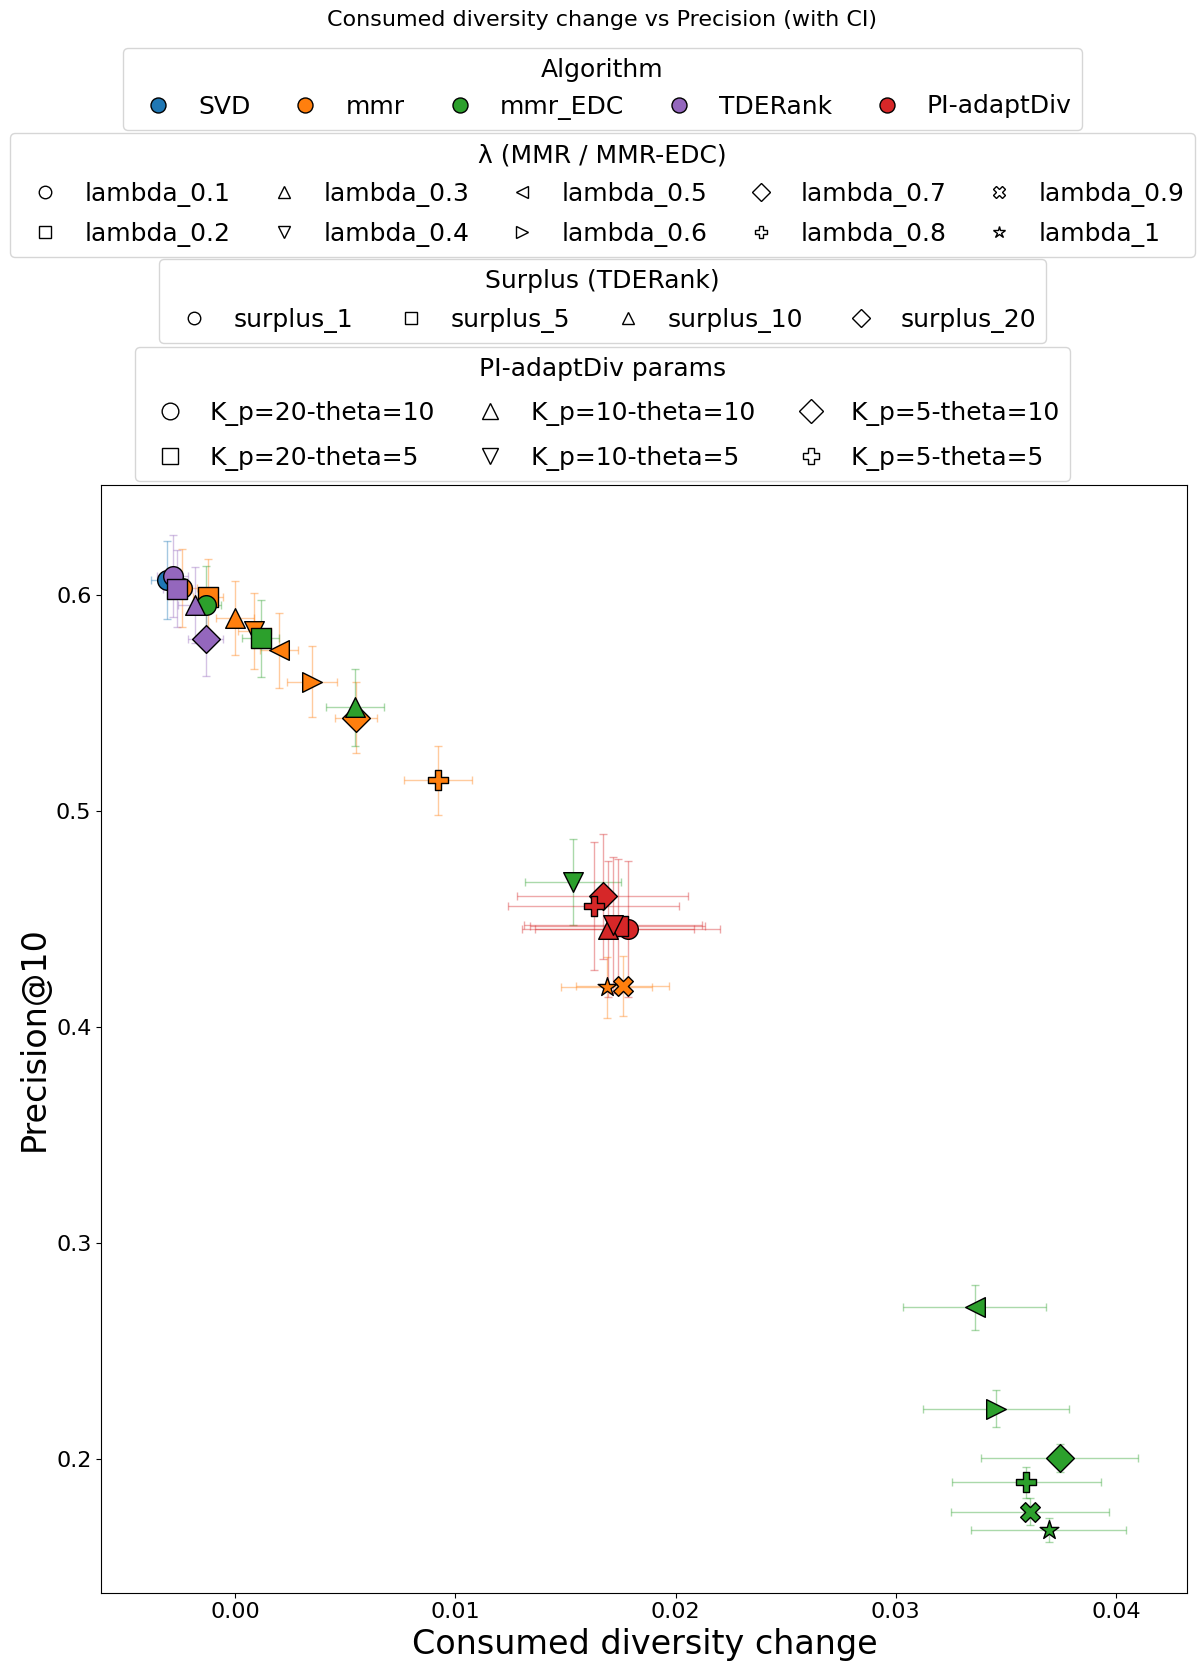

In [73]:
def get_precision_evolutions(users,simulation_type, parameters = None):
    precision_evolutions_all_users = {}
    if parameters is None:
        for user in users:
            if type(all_precision_evolutions[user][simulation_type]) == list:
                diversities = np.array(all_precision_evolutions[user][simulation_type])
            else:
                diversities = np.mean(np.array(list(all_precision_evolutions[user][simulation_type].values())), axis=0)
            precision_evolutions_all_users[user] = diversities
        return precision_evolutions_all_users
            
    else:
        for user in users:
            diversities = all_precision_evolutions[user][simulation_type][parameters]
            precision_evolutions_all_users[user] = diversities
        return precision_evolutions_all_users


def get_mean_precision_by_user(users,simulation_type, parameters = None):
    precision_evolution = get_precision_evolutions(users,simulation_type, parameters)
    mean_precision_all_users = {}
    for user in users:
        precisions = precision_evolution[user]
        mean_precision = np.mean(precisions)
        mean_precision_all_users[user] = mean_precision
    return mean_precision_all_users

def get_diversity_change_values(users, simulation_type, parameters=None):
    d = get_diversity_change(users, simulation_type, parameters)
    return np.array(list(d.values()), dtype=float)

def get_precision_values(users, simulation_type, parameters=None):
    per_user_mean = get_mean_precision_by_user(users, simulation_type, parameters)
    return np.array(list(per_user_mean.values()), dtype=float)



def plot_point_with_ci(x_vals, y_vals, color, marker,
                       alpha_ci=0.4, size=250):
    x_mean, x_err = mean_ci(x_vals)
    y_mean, y_err = mean_ci(y_vals)

    plt.errorbar(
        x_mean, y_mean,
        xerr=x_err, yerr=y_err,
        fmt="none",
        capsize=3,
        elinewidth=1,
        ecolor=color,
        alpha=alpha_ci,
        zorder=1
    )

    plt.scatter(
        x_mean, y_mean,
        s=size,
        marker=marker,
        facecolor=color,
        edgecolor="black",
        linewidth=1.0,
        zorder=2
    )
    return x_mean, y_mean

# =======================
# Marker maps (PARAMETERS ONLY)
# =======================
lambda_markers = ['o','s','^','v','<','>','D','P','X','*']
lambda_marker = dict(zip(lambdas, lambda_markers))

surplus_markers = ['o','s','^','D']
surplus_marker = dict(zip(surpluses, surplus_markers))

pi_markers = ['o','s','^','v','D','P']
pi_marker = dict(zip(pi_params, pi_markers))

# =======================
# Plot
# =======================


fig, ax = plt.subplots(figsize=(12, 17))
ax.tick_params(axis="both", which="major", labelsize=16)

# ---- your plotting loop (unchanged) ----
for algo, params in algo_parameters_structure.items():
    for p in params:
        x_vals = get_diversity_change_values(active_users, algo, p)
        y_vals = get_precision_values(active_users, algo, p)
        color = algo_colors[algo]

        if algo in ["mmr", "mmr_EDC"]:
            marker = lambda_marker[p]
        elif algo == "TDERank":
            marker = surplus_marker[p]
        elif algo == "PI-adaptDiv":
            marker = pi_marker[p]
        else:
            marker = "o"

        plot_point_with_ci(x_vals, y_vals, color=color, marker=marker,size=200)

ax.set_xlabel("Consumed diversity change", fontsize=24)
ax.set_ylabel("Precision@10", fontsize=24)

# =======================
# Legends ABOVE (same style as your 2x2 figure)
# =======================
fig.suptitle("Consumed diversity change vs Precision (with CI)", y=0.98, fontsize=16)

# make room above the axes for stacked legend rows
fig.subplots_adjust(top=0.68)

# ---- Algorithm legend (colors) ----
algo_handles = []
for alg in algo_parameters_structure.keys():
    algo_handles.append(
        Line2D([0],[0], marker='o', linestyle='None',
               markerfacecolor=algo_colors[alg], markeredgecolor='black',
               markersize=9, label=alg)
    )

fig.legend(
    handles=algo_handles,
    title="Algorithm",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(algo_handles),
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    markerscale=1.2,
    handletextpad=0.6,
    columnspacing=1.2,
)

# ---- λ legend (two lines, ncol=5) ----
lambda_handles = [
    Line2D([0],[0], marker=lambda_marker[l], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=l)
    for l in lambdas
]
fig.legend(
    handles=lambda_handles,
    title="λ (MMR / MMR-EDC)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.915),
    ncol=5,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.1,
    labelspacing=0.6
)

# ---- Surplus legend (one line) ----
surplus_handles = [
    Line2D([0],[0], marker=surplus_marker[s], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=s)
    for s in surpluses
]
fig.legend(
    handles=surplus_handles,
    title="Surplus (TDERank)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.841),
    ncol=4,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.3,
    labelspacing=0.6
)

# ---- PI params legend (wrap to 2 lines with ncol=3 like your snippet) ----
pi_handles = [
    Line2D([0],[0], marker=pi_marker[p], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=12, label=p)
    for p in pi_params
]
fig.legend(
    handles=pi_handles,
    title="PI-adaptDiv params",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.789),
    ncol=3,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.2,
    labelspacing=0.8
)

plt.tight_layout(rect=[0, 0, 1, 0.73])
plt.show()


## RQ2.1

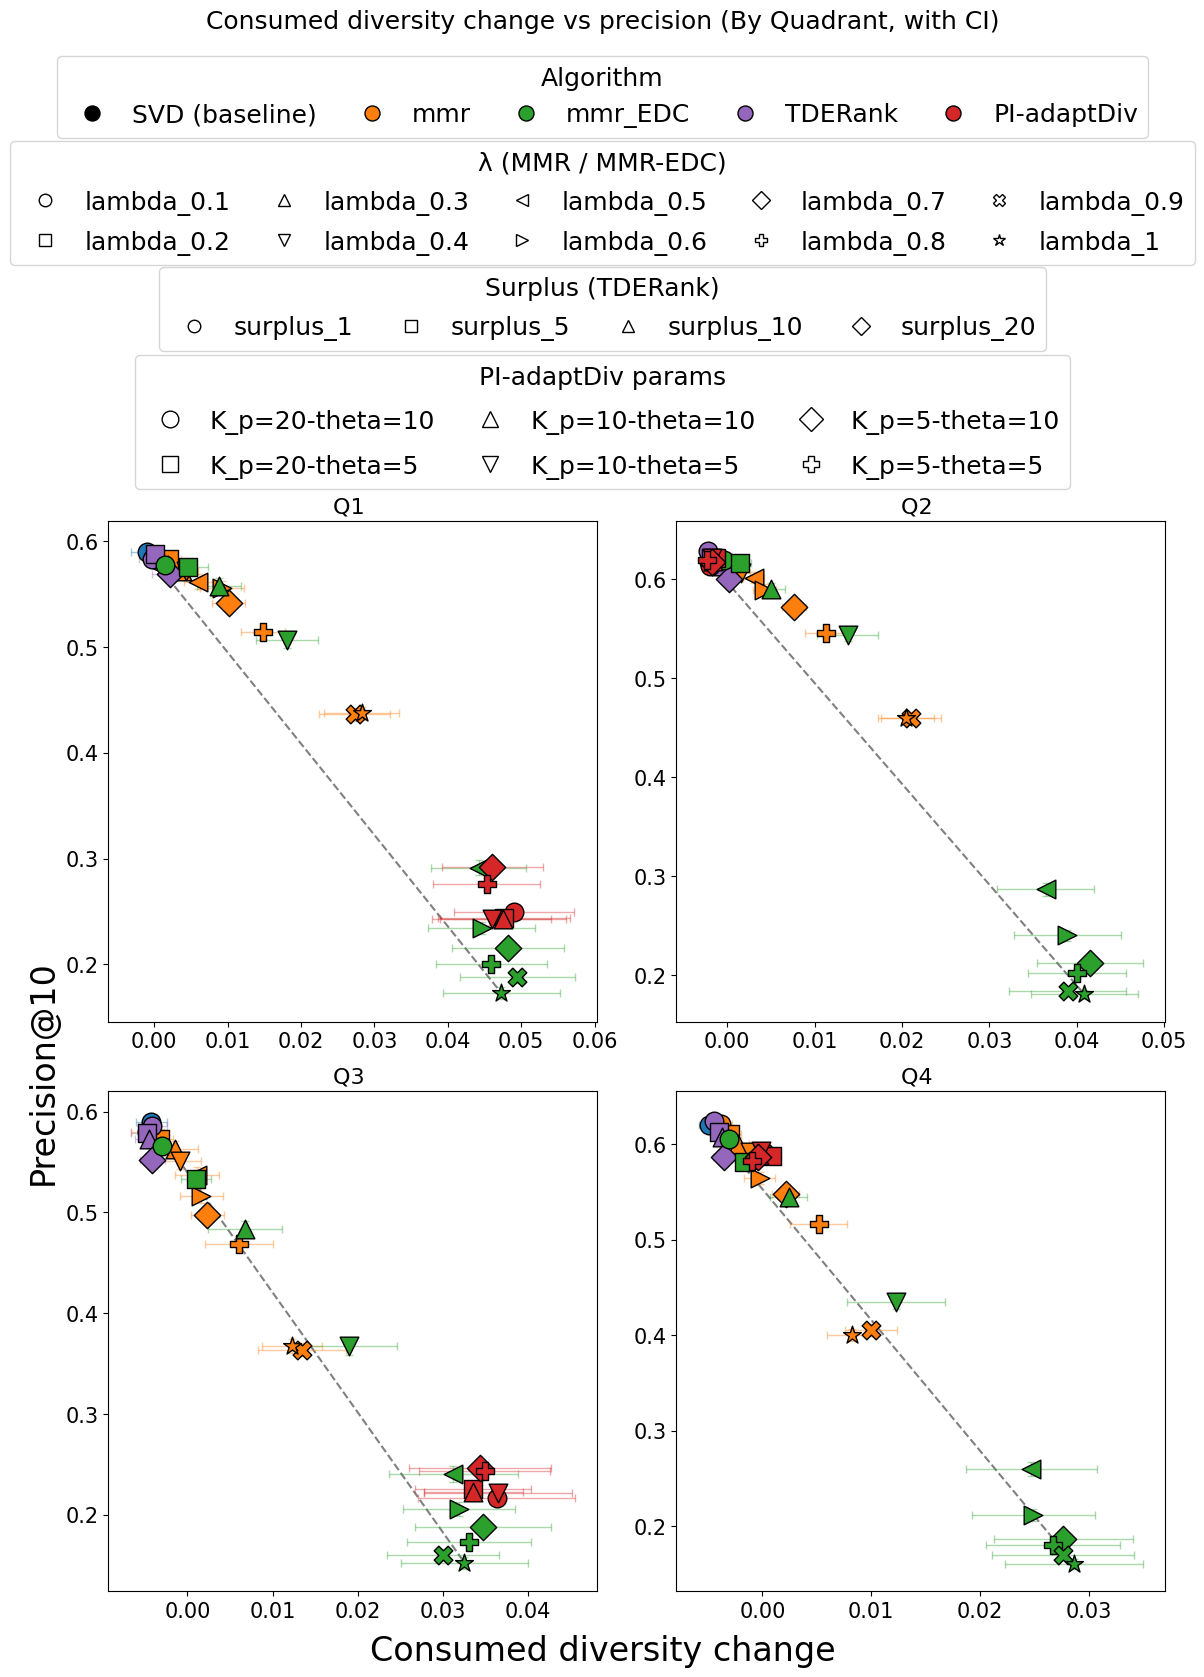

In [82]:
def scatter_with_ci(ax, x_vals, y_vals, *, color, marker, alpha_ci=0.4, size=180):
    x_mean, x_err = mean_ci(x_vals, 0.95)
    y_mean, y_err = mean_ci(y_vals, 0.95)

    # CI only (no legend)
    ax.errorbar(
        x_mean, y_mean,
        xerr=x_err, yerr=y_err,
        fmt="none",
        ecolor=color,
        elinewidth=1,
        capsize=3,
        alpha=alpha_ci,
        zorder=1
    )
    # point
    ax.scatter(
        x_mean, y_mean,
        s=size,
        marker=marker,
        facecolor=color,
        edgecolor="black",
        linewidth=1.0,
        zorder=2
    )
    return x_mean, y_mean

# -----------------------------
# Build full figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 17))
for ax in axes.ravel():
        ax.tick_params(axis="both", which="major", labelsize=15)
axes = axes.flatten()

for ax, (qname, qusers) in zip(axes, quad_users.items()):
    ax.set_title(f"{qname} ", fontsize=16)

    if len(qusers) == 0:
        ax.text(0.5, 0.5, "No users", ha='center', va='center')
        ax.set_xlabel("Consumed diversity change", fontsize=17)
        ax.set_ylabel("Precision@10", fontsize=17)
        continue

    # -------- Baseline SVD (for trend line) --------
    div_svd = list(get_diversity_change(qusers, 'SVD').values())
    prec_svd = list(get_precision_evolutions(qusers, 'SVD').values())
    x_svd, y_svd = scatter_with_ci(ax, div_svd, prec_svd, color=algo_colors["SVD"], marker="o")

    # -------- mmr (per lambda) --------
    for lam in lambdas:
        div_vals = list(get_diversity_change(qusers, 'mmr', lam).values())
        prec_vals = list(get_precision_evolutions(qusers, 'mmr', lam).values())
        scatter_with_ci(
            ax, div_vals, prec_vals,
            color=algo_colors["mmr"],
            marker=marker_for("mmr", lam)
        )

    # -------- TDERank (per surplus) --------
    for s in surpluses:
        div_vals = list(get_diversity_change(qusers, 'TDERank', s).values())
        prec_vals = list(get_precision_evolutions(qusers, 'TDERank', s).values())
        scatter_with_ci(
            ax, div_vals, prec_vals,
            color=algo_colors["TDERank"],
            marker=marker_for("TDERank", s)
        )

    # -------- mmr_EDC (per lambda) --------
    x_end = y_end = None
    for lam in lambdas:
        div_vals = list(get_diversity_change(qusers, 'mmr_EDC', lam).values())
        prec_vals = list(get_precision_evolutions(qusers, 'mmr_EDC', lam).values())
        x_m, y_m = scatter_with_ci(
            ax, div_vals, prec_vals,
            color=algo_colors["mmr_EDC"],
            marker=marker_for("mmr_EDC", lam)
        )
        if lam == "lambda_1":
            x_end, y_end = x_m, y_m

    # -------- PI-adaptDiv (per param) --------
    for param in pi_params:
        div_vals = list(get_diversity_change(qusers, 'PI-adaptDiv', param).values())
        prec_vals = list(get_precision_evolutions(qusers, 'PI-adaptDiv', param).values())
        scatter_with_ci(
            ax, div_vals, prec_vals,
            color=algo_colors["PI-adaptDiv"],
            marker=marker_for("PI-adaptDiv", param)
        )

    # Trend line: from SVD to MMR-EDC lambda_1
    if x_end is not None and y_end is not None:
        ax.plot([x_svd, x_end], [y_svd, y_end], color='gray', ls='--', zorder=0)



# -----------------------------
# Legends ABOVE (stacked, no overlap)
# -----------------------------
fig.suptitle("Consumed diversity change vs precision (By Quadrant, with CI)", y=0.985, fontsize=18)

fig.subplots_adjust(top=0.62)  # room for legends

# Algorithm legend (colors)
algo_handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor='black', markeredgecolor='black', markersize=9, label='SVD (baseline)'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["mmr"], markeredgecolor='black', markersize=9, label='mmr'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["mmr_EDC"], markeredgecolor='black', markersize=9, label='mmr_EDC'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["TDERank"], markeredgecolor='black', markersize=9, label='TDERank'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["PI-adaptDiv"], markeredgecolor='black', markersize=9, label='PI-adaptDiv'),
]
fig.legend(
    handles=algo_handles,
    title="Algorithm",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(algo_handles),
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    markerscale=1.2,
    handletextpad=0.6,
    columnspacing=1.2,
)

# ---- λ legend (two lines, ncol=5) ----
lambda_handles = [
    Line2D([0],[0], marker=lambda_marker[l], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=l)
    for l in lambdas
]
fig.legend(
    handles=lambda_handles,
    title="λ (MMR / MMR-EDC)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.915),
    ncol=5,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.1,
    labelspacing=0.6
)

# ---- Surplus legend (one line) ----
surplus_handles = [
    Line2D([0],[0], marker=surplus_marker[s], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=s)
    for s in surpluses
]
fig.legend(
    handles=surplus_handles,
    title="Surplus (TDERank)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.841),
    ncol=4,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.3,
    labelspacing=0.6
)

# ---- PI params legend (wrap to 2 lines with ncol=3 like your snippet) ----
pi_handles = [
    Line2D([0],[0], marker=pi_marker[p], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=12, label=p)
    for p in pi_params
]
fig.legend(
    handles=pi_handles,
    title="PI-adaptDiv params",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.789),
    ncol=3,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.2,
    labelspacing=0.8
)
fig.supxlabel("Consumed diversity change", fontsize=24)
fig.supylabel("Precision@10", fontsize=24, y=0.36)

plt.tight_layout(rect=[0, 0, 1, 0.73])
plt.show()


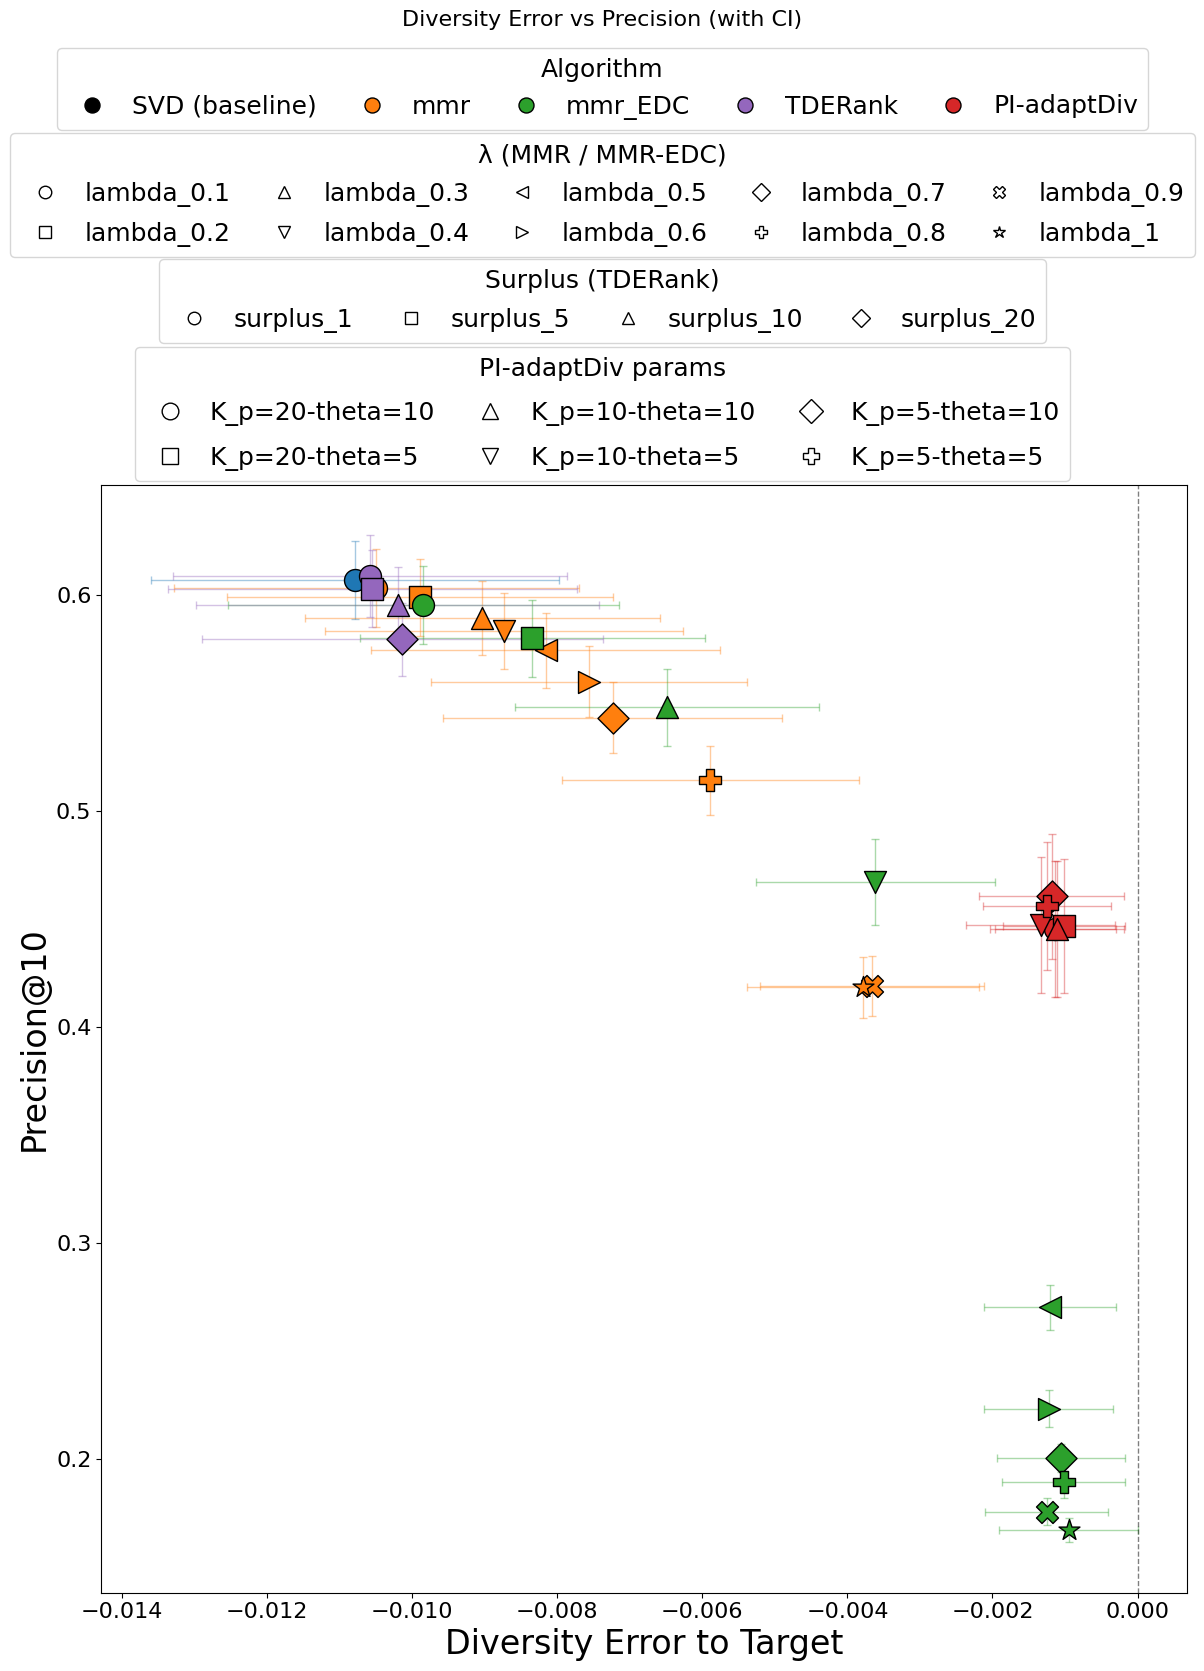

In [89]:
def neg_ReLU_i(x):
    x = np.asarray(x, dtype=float)
    return np.minimum(x, 0.0)


wanted_diversity = 0.5

fig, ax = plt.subplots(figsize=(12, 17))
ax.tick_params(axis="both", which="major", labelsize=16)


for algo, params in algo_parameters_structure.items():
    for p in params:
        # --- x: Mean Negative ReLU of Diversity Error (per user) ---
        final_diversity_vals = np.array(list(get_final_diversity(active_users, algo, p).values()), dtype=float)
        x_vals = neg_ReLU_i(final_diversity_vals - wanted_diversity)

        # --- y: Mean precision (per user) ---
        y_vals = np.array(list(get_mean_precision_by_user(active_users, algo, p).values()), dtype=float)

        color = algo_colors[algo]

        if algo in ["mmr", "mmr_EDC"]:
            marker = lambda_marker[p]
        elif algo == "TDERank":
            marker = surplus_marker[p]
        elif algo == "PI-adaptDiv":
            marker = pi_marker[p]
        else:
            marker = "o"

        plot_point_with_ci(x_vals, y_vals, color=color, marker=marker, size=250)

ax.set_xlabel("Diversity Error to Target", fontsize=24)
ax.set_ylabel("Precision@10", fontsize=24)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# =======================
# Legends ABOVE (same style)
# =======================
fig.suptitle("Diversity Error vs Precision (with CI)", y=0.98, fontsize=16)
fig.subplots_adjust(top=0.68)

# ---- Algorithm legend (colors) ----
algo_handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor='black', markeredgecolor='black', markersize=9, label='SVD (baseline)'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["mmr"], markeredgecolor='black', markersize=9, label='mmr'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["mmr_EDC"], markeredgecolor='black', markersize=9, label='mmr_EDC'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["TDERank"], markeredgecolor='black', markersize=9, label='TDERank'),
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=algo_colors["PI-adaptDiv"], markeredgecolor='black', markersize=9, label='PI-adaptDiv'),
]
fig.legend(
    handles=algo_handles,
    title="Algorithm",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(algo_handles),
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    markerscale=1.2,
    handletextpad=0.6,
    columnspacing=1.2,
)

# ---- λ legend (two lines, ncol=5) ----
lambda_handles = [
    Line2D([0],[0], marker=lambda_marker[l], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=l)
    for l in lambdas
]
fig.legend(
    handles=lambda_handles,
    title="λ (MMR / MMR-EDC)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.915),
    ncol=5,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.1,
    labelspacing=0.6
)

# ---- Surplus legend (one line) ----
surplus_handles = [
    Line2D([0],[0], marker=surplus_marker[s], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=9, label=s)
    for s in surpluses
]
fig.legend(
    handles=surplus_handles,
    title="Surplus (TDERank)",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.841),
    ncol=4,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.3,
    labelspacing=0.6
)

# ---- PI params legend (wrap to 2 lines with ncol=3 like your snippet) ----
pi_handles = [
    Line2D([0],[0], marker=pi_marker[p], linestyle='None',
           color='black', markerfacecolor='white', markeredgecolor='black',
           markersize=12, label=p)
    for p in pi_params
]
fig.legend(
    handles=pi_handles,
    title="PI-adaptDiv params",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.789),
    ncol=3,
    frameon=True,
    fontsize=18,
    title_fontsize=18,
    handletextpad=0.6,
    columnspacing=1.2,
    labelspacing=0.8
)


plt.tight_layout(rect=[0, 0, 1, 0.73])
plt.show()
